# DGA Detection: Autoencoder
The Autoencoder approach treats DGA detection as an unsupervised anomaly detection task. 
It is trained only on "normal" (benign) data. When it encounters a DGA domain, it will fail to reconstruct it accurately, 
resulting in a high "reconstruction error" (the anomaly score). This makes it much harder for new, unseen malware to by-pass the system.

## 1. Data Preparation

Filter the dataset so the model only sees benign domains during the training phase.

In [2]:
import string
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix
)

In [3]:
# Configuration and hyperparameters
MAX_SEQ_LEN = 75  
BATCH_SIZE = 128
LATENCY_REPS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Vocab
VOCAB = string.ascii_lowercase + string.digits + "-."
stoi = {ch: i + 1 for i, ch in enumerate(VOCAB)} 
VOCAB_SIZE = len(stoi) + 1

# Encodes domain string into a fixed-length integer sequence
def encode_domain(domain, seq_len=MAX_SEQ_LEN):
    encoded = [stoi.get(c, 0) for c in str(domain).lower()]
    encoded = encoded[:seq_len]
    encoded += [0] * (seq_len - len(encoded))
    return encoded

# Load data
df = pd.read_csv("/Users/maryam/Downloads/dga_data.csv").dropna(subset=['domain'])
df['encoded'] = df['domain'].apply(encode_domain)

# Split into Benign (for training) and Full (for evaluation)
X_all = np.array(df['encoded'].tolist())
y_all = (df['isDGA'] == 'dga').astype(int).values

# Filter training set
X_train_benign = X_all[y_all == 0]
X_train, X_val = train_test_split(X_train_benign, test_size=0.1, random_state=42)

# Convert to PyTorch Tensors
train_tensor = torch.tensor(X_train, dtype=torch.long)
val_tensor = torch.tensor(X_val, dtype=torch.long)
test_full_tensor = torch.tensor(X_all, dtype=torch.long)

## 2. Autoencoder Model

Autoencoder for DGA detection.
Aim of the model is to compresses a domain string into a latent space and attempts to reconstruct it. 

The model consists of:

- Embedding layer
- Linear Encoder to compress the sequence
- Decoder to reconstruct the character logits.

In [4]:
class DGAAutoencoder(nn.Module):

    def __init__(self, vocab_size, embed_dim=32, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(embed_dim * MAX_SEQ_LEN, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim * MAX_SEQ_LEN)
        )
        
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        batch_size = x.size(0)
        # Embedding
        emb = self.embedding(x)
        
        # Encode
        latent = self.encoder(emb)
        
        # Decode
        reconstructed_flat = self.decoder(latent)
        reconstructed_emb = reconstructed_flat.view(batch_size, MAX_SEQ_LEN, -1)
        
        # Project to Logits
        logits = self.output_layer(reconstructed_emb)
        return logits

# Initialize Model
ae_model = DGAAutoencoder(VOCAB_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss(reduction='none')

## 3. Training

Training on benign data focuses on minimizing the reconstruction loss for legitimate domain strings.

In [5]:
train_loader = DataLoader(train_tensor, batch_size=BATCH_SIZE, shuffle=True)

ae_model.train()

for epoch in range(30):
    epoch_loss = 0
    for batch in train_loader:
        x = batch.to(DEVICE)
        optimizer.zero_grad()

        logits = ae_model(x) 

        loss = criterion(logits.transpose(1, 2), x).mean()
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d} | Avg Loss: {avg_epoch_loss:.6f}")

Epoch 01 | Avg Loss: 0.538897
Epoch 02 | Avg Loss: 0.212594
Epoch 03 | Avg Loss: 0.104038
Epoch 04 | Avg Loss: 0.058037
Epoch 05 | Avg Loss: 0.038187
Epoch 06 | Avg Loss: 0.028334
Epoch 07 | Avg Loss: 0.022323
Epoch 08 | Avg Loss: 0.018192
Epoch 09 | Avg Loss: 0.015816
Epoch 10 | Avg Loss: 0.013956
Epoch 11 | Avg Loss: 0.012689
Epoch 12 | Avg Loss: 0.011933
Epoch 13 | Avg Loss: 0.011352
Epoch 14 | Avg Loss: 0.010749
Epoch 15 | Avg Loss: 0.010347
Epoch 16 | Avg Loss: 0.010060
Epoch 17 | Avg Loss: 0.009630
Epoch 18 | Avg Loss: 0.009511
Epoch 19 | Avg Loss: 0.009258
Epoch 20 | Avg Loss: 0.009086
Epoch 21 | Avg Loss: 0.008765
Epoch 22 | Avg Loss: 0.008705
Epoch 23 | Avg Loss: 0.008385
Epoch 24 | Avg Loss: 0.008486
Epoch 25 | Avg Loss: 0.008231
Epoch 26 | Avg Loss: 0.007972
Epoch 27 | Avg Loss: 0.007963
Epoch 28 | Avg Loss: 0.007985
Epoch 29 | Avg Loss: 0.007523
Epoch 30 | Avg Loss: 0.007660


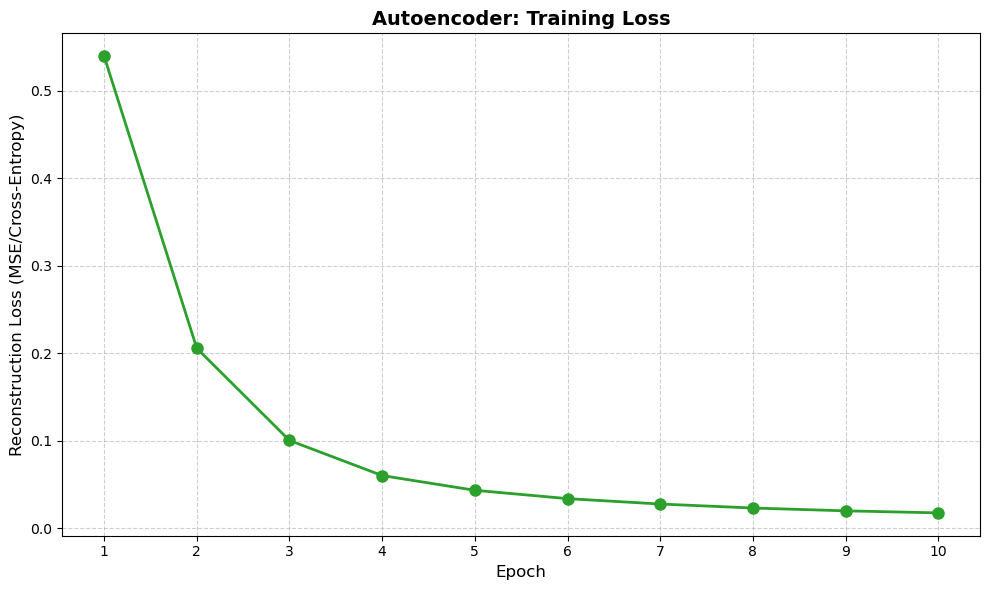

In [6]:
epochs = list(range(1, 11))
losses = [
    0.539320, 0.205747, 0.100501, 0.060401, 0.043577,
    0.034061, 0.027891, 0.023341, 0.020116, 0.017779
]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linestyle='-', color='#2ca02c', linewidth=2, markersize=8)

# Add titles and labels
plt.title('Autoencoder: Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE/Cross-Entropy)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Anomaly Detection & Inference Latency
Calculate the reconstruction error for the entire test set (benign + DGA) to find anomaly score.

In [7]:
ae_model.eval()
test_loader = DataLoader(test_full_tensor, batch_size=256, shuffle=False)
anomaly_scores = []

start_time = time.perf_counter()
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        logits = ae_model(x)

        char_losses = criterion(logits.transpose(1, 2), x)

        sample_losses = char_losses.mean(dim=1)
        anomaly_scores.extend(sample_losses.cpu().numpy())

total_time = (time.perf_counter() - start_time)
latency_ms = (total_time / len(X_all)) * 1000
anomaly_scores = np.array(anomaly_scores)

precisions, recalls, thresholds = precision_recall_curve(y_all, anomaly_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (anomaly_scores >= best_threshold).astype(int)

auc_roc = roc_auc_score(y_all, anomaly_scores)
pr_auc = average_precision_score(y_all, anomaly_scores)
precision = precision_score(y_all, y_pred)
recall = recall_score(y_all, y_pred)
f1 = f1_score(y_all, y_pred)

# False Positive Rate
tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
fpr = fp / (fp + tn)

print(f"--- Autoencoder Results ---")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"AUC-ROC:           {auc_roc:.4f}")
print(f"PR-AUC:            {pr_auc:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"FPR:               {fpr:.4f}")
print(f"Inference Latency: {latency_ms:.4f} ms/sample")
print(f"Parameter Count:   {sum(p.numel() for p in ae_model.parameters()):,}")

--- Autoencoder Results ---
Optimal Threshold: 0.0010
AUC-ROC:           0.8857
PR-AUC:            0.9011
F1-Score:          0.8362
Precision:         0.8445
Recall:            0.8280
FPR:               0.1525
Inference Latency: 0.0107 ms/sample
Parameter Count:   627,815


In [8]:
ae_model.eval()
test_loader = DataLoader(test_full_tensor, batch_size=256, shuffle=False)
anomaly_scores = []

start_time = time.perf_counter()
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        logits = ae_model(x)
        char_losses = criterion(logits.transpose(1, 2), x)
        sample_losses = char_losses.mean(dim=1)
        anomaly_scores.extend(sample_losses.cpu().numpy())

total_time = (time.perf_counter() - start_time)
global_mean_latency = (total_time / len(X_all)) * 1000
anomaly_scores = np.array(anomaly_scores)

precisions, recalls, thresholds = precision_recall_curve(y_all, anomaly_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

y_pred = (anomaly_scores >= best_threshold).astype(int)
auc_roc = roc_auc_score(y_all, anomaly_scores)
f1 = f1_score(y_all, y_pred)
prec = precision_score(y_all, y_pred)
rec = recall_score(y_all, y_pred)

tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
fpr = fp / (fp + tn)

latencies = []
dummy_input = torch.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN)).to(DEVICE)
for _ in range(1000):
    start = time.perf_counter()
    with torch.no_grad():
        _ = ae_model(dummy_input)
    latencies.append((time.perf_counter() - start) * 1000)

mean_lat = np.mean(latencies)
p99_lat = np.percentile(latencies, 99)
params = sum(p.numel() for p in ae_model.parameters())

final_results = pd.DataFrame({
    "Model": ["Autoencoder"],
    "Threshold": [f"{best_threshold:.6f}"],
    "AUC-ROC": [f"{auc_roc:.4f}"],
    "FPR": [f"{fpr:.4f}"],
    "Precision": [f"{prec:.4f}"],
    "Recall": [f"{rec:.4f}"],
    "F1": [f"{f1:.4f}"],
    "Parameters": [f"{params:,}"],
    "Mean Latency (ms)": [f"{mean_lat:.4f}"],
    "P99 Latency (ms)": [f"{p99_lat:.4f}"]
})

print("--- Autoencoder Evaluation ---")
display(final_results)

--- Autoencoder Evaluation ---


,Model,Threshold,AUC-ROC,FPR,Precision,Recall,F1,Parameters,Mean Latency (ms),P99 Latency (ms)
0,Autoencoder,0.001018,0.8857,0.1525,0.8445,0.8280,0.8362,"627,815",0.0684,0.0960


## 5. Leave One Family Out Evaluation

Mean LOFO F1 Score: 0.4633


,DGA Family (Subclass),AE LOFO F1 Score,N Samples
1,cryptolocker,0.811831,37254
2,newgoz,0.603337,9276
0,gameoverdga,0.581133,8461
4,goz,0.501533,6136
5,necurs,0.465942,8331
6,bamital,0.254872,2086
3,nivdort,0.024676,8456


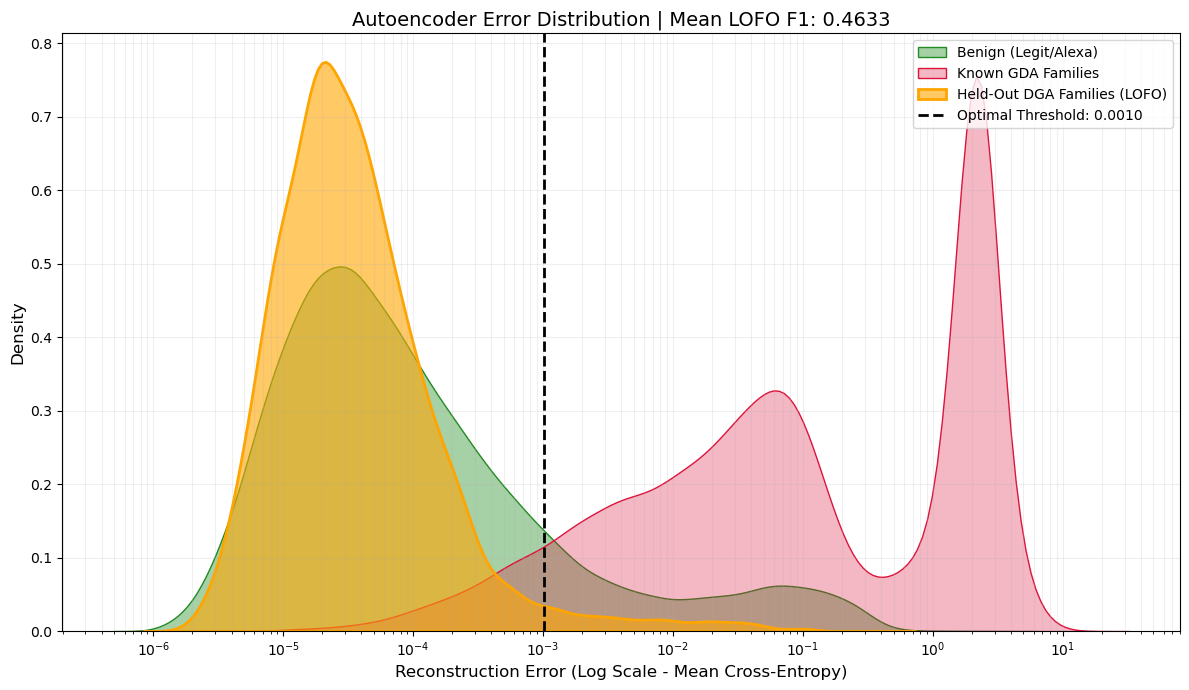

--- Comparative Analysis ---
AE Mean LOFO F1:    0.4633
LR Mean LOFO F1:    0.1122
Improvement vs LR:  +0.3511


In [9]:
results_df = pd.DataFrame({
    'family': df['subclass'].values, 
    'y_true': y_all,              
    'score': anomaly_scores       
})
results_df['y_pred'] = (results_df['score'] >= best_threshold).astype(int)

lofo_stats = []

benign_labels = ['legit', 'alexa']
dga_families = [f for f in results_df['family'].unique() if f not in benign_labels]

for held_out_family in dga_families:
    mask = results_df['family'].isin(benign_labels + [held_out_family])
    subset = results_df[mask]
    
    f1 = f1_score(subset['y_true'], subset['y_pred'])
    n_samples = (results_df['family'] == held_out_family).sum()
    
    lofo_stats.append({
        "DGA Family (Subclass)": held_out_family,
        "AE LOFO F1 Score": f1,
        "N Samples": n_samples
    })

lofo_report = pd.DataFrame(lofo_stats).sort_values(by="AE LOFO F1 Score", ascending=False)
mean_lofo_f1 = lofo_report['AE LOFO F1 Score'].mean()

print(f"Mean LOFO F1 Score: {mean_lofo_f1:.4f}")
display(lofo_report)

plt.figure(figsize=(12, 7))

# Separate scores for plotting
benign_scores = results_df[results_df['family'].isin(benign_labels)]['score']
nivdort_scores = results_df[results_df['family'] == 'nivdort']['score']
other_dga_scores = results_df[(results_df['y_true'] == 1) & (results_df['family'] != 'nivdort')]['score']

sns.kdeplot(benign_scores + 1e-6, fill=True, color='forestgreen', label='Benign (Legit/Alexa)', alpha=0.4, log_scale=True)
sns.kdeplot(other_dga_scores + 1e-6, fill=True, color='crimson', label='Known GDA Families', alpha=0.3, log_scale=True)
sns.kdeplot(nivdort_scores + 1e-6, fill=True, color='orange', label='Held-Out DGA Families (LOFO)', alpha=0.6, log_scale=True, linewidth=2)

# Add Threshold
plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Optimal Threshold: {best_threshold:.4f}')

plt.title(f'Autoencoder Error Distribution | Mean LOFO F1: {mean_lofo_f1:.4f}', fontsize=14)
plt.xlabel('Reconstruction Error (Log Scale - Mean Cross-Entropy)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

lr_baseline_lofo = 0.1122
print(f"--- Comparative Analysis ---")
print(f"AE Mean LOFO F1:    {mean_lofo_f1:.4f}")
print(f"LR Mean LOFO F1:    {lr_baseline_lofo:.4f}")
print(f"Improvement vs LR:  {mean_lofo_f1 - lr_baseline_lofo:+.4f}")